✅ Dataset Loaded Successfully

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

📊 Model Evaluation Results:
Accuracy: 100.00%

Confusion Matrix:
 [[15  0  0]
 [ 0 15  0]
 [ 0  0 15]]

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       1.00      1.00      1.00        15
 Iris-virginica       1.00      1.00      1.00        15

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.

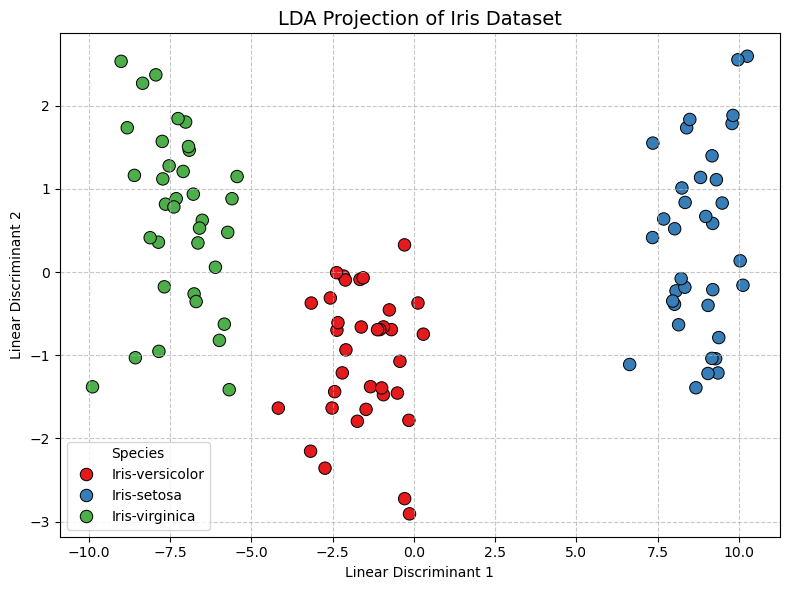

In [6]:
#%% -------------------------------
# Linear Discriminant Analysis (LDA) on Iris Dataset
# Objective: Apply LDA Algorithm on Iris Dataset and classify which species a given flower belongs to.
# Dataset Link: https://www.kaggle.com/datasets/uciml/iris
#%% -------------------------------

# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 2: Load the dataset
df = pd.read_csv("Iris.csv")  # Ensure the file is in your working directory
print("✅ Dataset Loaded Successfully\n")
print(df.head())

# Step 3: Separate features and target variable
X = df.iloc[:, :-1].values     # Features: Sepal Length, Sepal Width, Petal Length, Petal Width
y = df.iloc[:, -1].values      # Target: Species

# Step 4: Split the dataset into training and testing sets (70:30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Step 5: Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 6: Apply Linear Discriminant Analysis (LDA)
lda = LinearDiscriminantAnalysis(n_components=2)
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

# Step 7: Train the LDA Classifier
lda.fit(X_train, y_train)

# Step 8: Make predictions
y_pred = lda.predict(X_test)

# Step 9: Evaluate performance
print("\n📊 Model Evaluation Results:")
print("Accuracy: {:.2f}%".format(accuracy_score(y_test, y_pred) * 100))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Step 10: Visualize the LDA-transformed data (2D projection)
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_train_lda[:, 0],
    y=X_train_lda[:, 1],
    hue=y_train,
    palette='Set1',
    s=80,
    edgecolor='k'
)
plt.title('LDA Projection of Iris Dataset', fontsize=14)
plt.xlabel('Linear Discriminant 1')
plt.ylabel('Linear Discriminant 2')
plt.legend(title='Species', loc='best')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
